---
title: "Pauli Correlation Encoding for Qubit-Efficient MaxCut"
author: "Elisabeth Welizky, Adapted by Adelina Bärligea"
date: "2026-08-31"
categories: [code, quantum optimization]
image: "preview.png"
image-width: "1cm"
image-height: "1cm"
bibliography: "references.bib"
csl: "ieee.csl"
link-citations: true
format:
  html:
    code-fold: false
    toc: true
    cap-location: bottom
jupyter: blogqa
execute:
  enabled: false
---

Many quantum algorithms for binary optimization such as QAOA [@farhi2014qaoa] use one qubit for each decision variable, making the register size a direct bottleneck when trying to solve large instances. Pauli Correlation Encoding (PCE) [@sciorilli2025pce] instead represents binary variables through multi-qubit Pauli correlations, resulting in a polynomial compression of the problem's space requirements [@alonso2026benchmarkpaulicorrelationencoding; @friedhoff2026]. This tutorial constructs the method in Tequila, follows a three-node MaxCut example from Pauli strings to a decoded partition, and examines the solution behavior observed in a numerical parameter study.

## From MaxCut to Pauli correlations

### MaxCut

Before introducing the PCE principle, we first consider MaxCut, one of the most widely studied NP-hard combinatorial optimization problems and a canonical benchmark for quantum optimization methods [@kochenberger; @maxCut; @farhi2014qaoa].

Given an undirected weighted graph $G=(V,E,w)$ with $N=|V|$ nodes and edge weights $w_{ij} \geq 0$, a spin assignment $z_i\in\{-1,+1\}$ places each node in one of two partitions. Its cut value is

$$
C_G(z)=\sum_{(i,j)\in E}\frac{w_{ij}}{2}\left(1-z_i z_j\right),
$$

where an edge $(i,j)\in E$ contributes its weight exactly when its two connected nodes are in different partitions, i.e., $z_i,z_j$ have opposite signs. MaxCut then asks for the assignment with the largest cut value.

![](MaxCut.png){#fig-MaxCut width=50% fig-align="center"}

The partition in @fig-MaxCut separates the vertices into $\{1,3,4\}$ and $\{2,5\}$; the highlighted crossing edges determine the cut value.

### Pauli Correlation Encoding

PCE does not store a variable in the computational state of one dedicated qubit. Instead, a variable $i$ is assigned to

- a $k$-qubit support $s(i)\subseteq\{0,\ldots,n-1\}$,
- a Pauli axis $p(i)\in\{X,Y,Z\}$, and
- the corresponding Pauli string

$$
\Pi_i=\prod_{q\in s(i)}p(i)_q.
$$

The final binary value $z_i$ is then decoded from a variational state $|\psi(\theta)\rangle$ via

$$
z_i=\operatorname{sgn}\!\left(\langle\psi(\theta)|\Pi_i|\psi(\theta)\rangle\right).
$$

Using every $k$-qubit support once within each Pauli family provides up to $3\binom{n}{k}$ variables. All $X$-type strings, all $Y$-type strings, and all $Z$-type strings can be measured in three global basis settings, respectively [@sciorilli2025pce].

![](PCE_qubits.png){#fig-PCE-qubits width=70% fig-align="center"}

@fig-PCE-qubits illustrates the quadratic case $N=9$, $n=3$, and $k=2$. Concretely, the nine possible encodings are

$$
\{X_0X_1,Y_0Y_1,Z_0Z_1,X_0X_2,Y_0Y_2,Z_0Z_2,X_1X_2,Y_1Y_2,Z_1Z_2\}.
$$

This assignment represents nine optimization variables with only three qubits and makes the relation $n<N$ concrete. Note that the Pauli assignment is part of the encoding and does not depend on whether two graph vertices are adjacent.

## Constructing the encoding in Tequila

We begin with the imports used throughout the tutorial.

In [2]:
import numpy as np
import networkx as nx
import tequila as tq
from scipy.optimize import minimize
from itertools import combinations
import random

### Divide variables among Pauli families

For nine variables, the standard three-Pauli encoding divides the indices into equally sized $X$, $Y$, and $Z$ groups.

In [3]:
#| code-fold: true
#| code-summary: "Show the three-family variable split"
num_nodes = 9  # example: 9 optimization variables

list_size = num_nodes // 3
node_x = [i for i in range(list_size)]
node_y = [i for i in range(list_size, 2 * list_size)]
node_z = [i for i in range(2 * list_size, num_nodes)]

print("X-group:", node_x)
print("Y-group:", node_y)
print("Z-group:", node_z)

X-group: [0, 1, 2]
Y-group: [3, 4, 5]
Z-group: [6, 7, 8]


While the standard formulation usually relies on all three Pauli operators $X$, $Y$, $Z$, this tutorial assesses, whether a two-operator scheme, which is structually simpler, will achieve comparable performance. For this, it compares three restricted encodings:

| Case | Pauli families |
|---|---|
| 1 | $X,Y,Z$ |
| 2 | $X,Y$ |
| 3 | $X,Z$ |
| 4 | $Y,Z$ |

In Case 1, the implementation assigns $\lfloor N/3\rfloor$ variables to $X$, the same number to $Y$, and the remaining variables to $Z$. In Cases 2--4, the first family receives $\lfloor N/2\rfloor$ variables and the second receives the remainder. This convention is kept fixed when the cases are compared.

In [4]:
#| code-fold: true
#| code-summary: "Show all four Pauli-family assignments"
case = 1  # 1: X,Y,Z   2: X,Y   3: X,Z   4: Y,Z

node_x, node_y, node_z = [], [], []

if case == 1:
    list_size = num_nodes // 3
    node_x = [i for i in range(list_size)]
    node_y = [i for i in range(list_size, 2 * list_size)]
    node_z = [i for i in range(2 * list_size, num_nodes)]

elif case == 2:
    list_size = num_nodes // 2
    node_x = [i for i in range(list_size)]
    node_y = [i for i in range(list_size, num_nodes)]

elif case == 3:
    list_size = num_nodes // 2
    node_x = [i for i in range(list_size)]
    node_z = [i for i in range(list_size, num_nodes)]

elif case == 4:
    list_size = num_nodes // 2
    node_y = [i for i in range(list_size)]
    node_z = [i for i in range(list_size, num_nodes)]

print("Distribution of variables: ", node_x, node_y, node_z)

Distribution of variables:  [0, 1, 2] [3, 4, 5] [6, 7, 8]


### Assign $k$-qubit correlations

For a selected Pauli family, the construction proceeds in four steps:

1. Generate all $\binom{n}{k}$ supports of size $k$.
2. Shuffle the support list.
3. Assign each variable in the family a support pattern that has not yet been used by that family.
4. Multiply the selected single-qubit Pauli operator over the assigned support.

For four qubits and $k=2$, for example, the available supports are $(0,1)$, $(0,2)$, $(0,3)$, $(1,2)$, $(1,3)$, and $(2,3)$. Which variable receives which combination is therefore random, but every support remains unique within a Pauli family.

For example, assigning support $(0,1)$ to an $X$-type variable produces $\Pi_i=X_0X_1$. Different Pauli families may reuse the same support because the Pauli axis still distinguishes the resulting strings.

In [5]:
#| code-fold: true
#| code-summary: "Show the Pauli correlation encoding function"
def build_pauli_correlation_encoding(pauli_type, node_list, num_qubits, k=2):
    all_combos = list(combinations(range(num_qubits), k))
    random.shuffle(all_combos)

    used_combos = set()
    pauli_encodings = []

    for node in node_list:
        assigned_combo = None
        for combo in all_combos:
            if combo in used_combos:
                continue
            assigned_combo = combo
            break

        if assigned_combo is None:
            raise ValueError(f"Cannot assign valid combination for node {node}.")

        used_combos.add(assigned_combo)

        pauli_op = None
        for qubit_idx in assigned_combo:
            if pauli_type == "X":
                single_pauli = tq.paulis.X(qubit_idx)
            elif pauli_type == "Y":
                single_pauli = tq.paulis.Y(qubit_idx)
            elif pauli_type == "Z":
                single_pauli = tq.paulis.Z(qubit_idx)
            pauli_op = single_pauli if pauli_op is None else pauli_op * single_pauli

        pauli_encodings.append(pauli_op)

    return pauli_encodings

example_encodings = build_pauli_correlation_encoding("X", node_x, num_qubits=4, k=2)
print("Example with 4 qubits, k=2, applied to the X-group", example_encodings)

Example with 4 qubits, k=2, applied to the X-group [+1.0000X(0)X(3), +1.0000X(0)X(2), +1.0000X(0)X(1)]


### Determine the required number of qubits

Let $M$ denote the size of the largest Pauli family. The encoding is feasible whenever

$$
\binom{n}{k}\geq M.
$$

Under the grouping convention above,

$$
M=
\begin{cases}
\left\lfloor N/3\right\rfloor+(N\bmod 3), & \text{Case 1},\\
\left\lceil N/2\right\rceil, & \text{Cases 2--4}.
\end{cases}
$$

For $k=2$, solving $\binom{n}{2}\geq M$ gives

$$
n_{\min}=
\left\lceil\frac{1+\sqrt{1+8M}}{2}\right\rceil.
$$

For a fixed locality $k$, this capacity relation gives $n_{\min}=\Theta(N^{1/k})$. Note that this is a statement about register size, and it cannot by itself determine circuit depth, parameter count, optimization difficulty, or total runtime.

In [6]:
#| code-fold: true
#| code-summary: "Show the minimum-qubit calculation"
def min_num_qubits(num_nodes, k, case=1):
    if case == 1:
        max_connections = num_nodes // 3 + num_nodes % 3
    elif case in [2, 3, 4]:
        max_connections = (num_nodes + 1) // 2
    else:
        raise ValueError(f"Invalid case: {case}")

    n = k
    while True:
        binom = 1.0
        for i in range(1, k + 1):
            binom *= (n + 1 - i) / i
        if binom >= max_connections:
            return n
        n += 1

print("Minimum number of qubits: ",min_num_qubits(num_nodes, k=2, case=1))

Minimum number of qubits:  3


### Build the variational circuit

After assigning the Pauli combinations to the variables, the ansatz must be built. The tutorial uses a hardware-efficient circuit [@kandala2017hea] with alternating $R_y$ and $R_z$ rotations followed by a nearest-neighbor CNOT chain, which is a sufficiently expressive ansatz that is easily implementable on near-term quantum devices.

In [7]:
#| code-fold: true
#| code-summary: "Show the variational circuit construction"
def build_ansatz(num_qubits, reps):
    """Build ansatz with Ry and Rz gates"""
    U = tq.QCircuit()

    param_idx = 0
    for rep in range(reps):
        for i in range(num_qubits):
            U += tq.gates.Ry(angle=f"theta_{param_idx}", target=i)
            param_idx += 1
            U += tq.gates.Rz(angle=f"theta_{param_idx}", target=i)
            param_idx += 1
        for i in range(num_qubits - 1):
            U += tq.gates.CX(control=i, target=i + 1)

    return U

ansatz = build_ansatz(num_qubits=4, reps=2)

## Example: a three-node MaxCut instance

A mechanism is now needed to tell how good the quantum state $|\psi(\theta)\rangle$ is in terms of maximizing the cut. The cost function prepares the state, computes the Pauli expectation values, maps them back to graph nodes, and evaluates the relaxed MaxCut loss.

We now follow one complete optimization for a triangle graph. Case 1 assigns one graph vertex to each Pauli family. With $k=2$, the minimum register contains two qubits, and the three variables are represented by the $XX$, $YY$, and $ZZ$ correlators on that pair.

### 1. Construct the encoded observables

The dictionary below stores the Pauli observables by family. The helper function preserves the variable order when the expectation values are mapped back to graph nodes.

In [8]:
#| code-fold: true
#| code-summary: "Show the triangle encoding setup"
# Example with 3 nodes and case 1 (X, Y, Z)
num_nodes = 3
list_size = num_nodes // 3
node_x = [i for i in range(list_size)]
node_y = [i for i in range(list_size, 2 * list_size)]
node_z = [i for i in range(2 * list_size, num_nodes)]

num_qubits = min_num_qubits(num_nodes, k=2, case=1)

pauli_encodings = {}
pauli_encodings["X"] = build_pauli_correlation_encoding("X", node_x, num_qubits, k=2) if node_x else []
pauli_encodings["Y"] = build_pauli_correlation_encoding("Y", node_y, num_qubits, k=2) if node_y else []
pauli_encodings["Z"] = build_pauli_correlation_encoding("Z", node_z, num_qubits, k=2) if node_z else []

def map_expectation_values_to_nodes(expectation_values, pauli_encodings, node_x, node_y, node_z):
    node_exp_map = {}
    idx = 0
    for pauli_type, node_list in [('X', node_x), ('Y', node_y), ('Z', node_z)]:
        for i in range(len(pauli_encodings[pauli_type])):
            if i < len(node_list):
                node_exp_map[node_list[i]] = expectation_values[idx]
            idx += 1
    return node_exp_map

print("qubits:", "X:", node_x, "Y:", node_y, "Z:", node_z)

qubits: X: [0] Y: [1] Z: [2]


### 2. Evaluate the Pauli correlations

For each encoded observable $\Pi_i$, Tequila constructs

$$
e_i(\theta)=\langle\psi(\theta)|\Pi_i|\psi(\theta)\rangle\in[-1,1].
$$

The expectation values are returned as a flat list in the same fixed order used above, $X\rightarrow Y\rightarrow Z$, before they are mapped into a dictionary keyed by graph vertices.

The observables are evaluated at a small illustrative parameter vector and then associated with the corresponding graph vertices.

In [9]:
#| code-fold: true
#| code-summary: "Show the expectation-value evaluation"
ansatz = build_ansatz(num_qubits, reps=2)
variables = sorted(ansatz.extract_variables())

exp_vals = []
for H in pauli_encodings['X']:
    exp_vals.append(tq.ExpectationValue(H=H, U=ansatz))
for H in pauli_encodings['Y']:
    exp_vals.append(tq.ExpectationValue(H=H, U=ansatz))
for H in pauli_encodings['Z']:
    exp_vals.append(tq.ExpectationValue(H=H, U=ansatz))

# simulate for an example parameter set
param_dict = {var: 0.01 for var in variables}

expectation_values = []
for exp_val in exp_vals:
    result = tq.simulate(exp_val, variables=param_dict, backend="qulacs")
    expectation_values.append(float(result))

node_exp_map = map_expectation_values_to_nodes(expectation_values, pauli_encodings, node_x, node_y, node_z)
print(node_exp_map)

{0: 0.010098800054376493, 1: -0.009897341981725516, 2: 0.9997500170828262}


### 3. Relax the MaxCut loss function

Maximizing the cut value is equivalent, up to an additive constant and a positive factor, to minimizing the Ising energy

$$
E_G(z)=\sum_{(i,j)\in E}w_{ij}z_i z_j
$$

for nonnegative edge weights [@lucas2014ising]. PCE replaces each discrete spin by the smooth quantity

$$
y_i(\theta)=\tanh\!\left(\alpha e_i(\theta)\right).
$$

The sign function is used only for the final decoding. During optimization, $\tanh$ supplies a smooth surrogate; the scale $\alpha>1$ keeps small correlators from remaining entirely in its nearly linear regime [@sciorilli2025pce; @alonso2026benchmarkpaulicorrelationencoding].

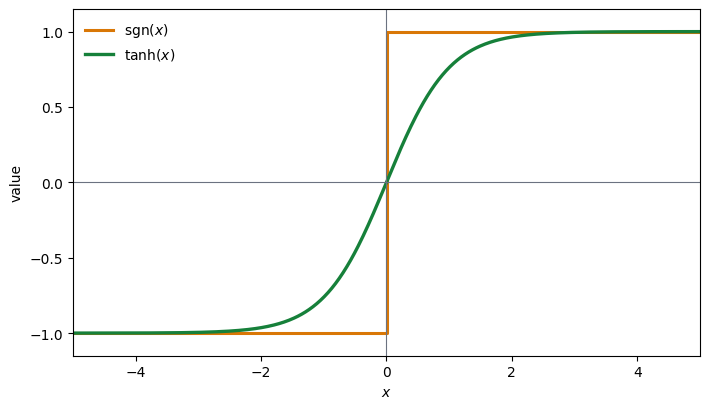

In [10]:
#| code-fold: true
#| code-summary: "Show the plotting code"
import matplotlib.pyplot as plt

x = np.linspace(-5.0, 5.0, 500)
sign_x = np.where(x >= 0.0, 1.0, -1.0)
smooth_x = np.tanh(x)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.step(x, sign_x, where="post", color="#d97706", linewidth=2.2, label=r"$\operatorname{sgn}(x)$")
ax.plot(x, smooth_x, color="#16803a", linewidth=2.4, label=r"$\tanh(x)$")
ax.axhline(0.0, color="#6b7280", linewidth=0.8)
ax.axvline(0.0, color="#6b7280", linewidth=0.8)
ax.set(xlabel=r"$x$", ylabel="value", xlim=(-5, 5), ylim=(-1.15, 1.15))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

The sign function is a step function: it remains constant on either side of zero and jumps abruptly from $-1$ to $+1$. The $\tanh$ function instead varies smoothly and continuously, as the plot above illustrates.

The implemented MaxCut loss is

$$
\mathcal{L}(\theta)=
\sum_{(i,j)\in E}w_{ij}y_i(\theta)y_j(\theta)
+\beta\nu
\left[
\frac{1}{N}\sum_{i=1}^{N}y_i(\theta)^2
\right]^2.
$$

The first term favors opposite signs on adjacent vertices. The regularizer penalizes large correlator magnitudes and keeps the optimization in a region where more sign patterns remain accessible; it does not directly prefer one partition over another because it depends only on $y_i^2$ [@sciorilli2025pce]. The primary PCE prescription uses the Edwards--Erdos scale $\nu=|E|/2+(N-1)/4$. In the implementation below, each undirected edge weight is stored in both orientations, so `total_edge_weight / 2` evaluates to $|E|$ and the objective uses $\nu=|E|+(N-1)/4$ instead. In either convention, $\beta$ controls the regularization strength.

In [11]:
#| code-fold: true
#| code-summary: "Show the relaxed MaxCut loss calculation"
example_graph = nx.Graph()
example_graph.add_weighted_edges_from([(0, 1, 1.0), (1, 2, 1.0), (0, 2, 1.0)])

edges = example_graph.edges()
edge_weights = {}
for u, v, data in example_graph.edges(data=True):
    w = data.get('weight', 1.0)
    edge_weights[(u, v)] = w
    edge_weights[(v, u)] = w

external_field = np.zeros(num_nodes)

alpha = num_qubits
loss = 0
for edge in edges:
    edge0, edge1 = edge[0], edge[1]
    if edge0 in node_exp_map and edge1 in node_exp_map:
        weight = edge_weights.get((edge0, edge1), 0.0)
        loss += weight * np.tanh(alpha * node_exp_map[edge0]) * np.tanh(alpha * node_exp_map[edge1])

if np.any(external_field != 0):
    for i in range(num_nodes):
        if i in node_exp_map:
            loss += external_field[i] * np.tanh(alpha * node_exp_map[i])

regulation_term = 0
for i in range(num_nodes):
    if i in node_exp_map:
        regulation_term += np.tanh(alpha * node_exp_map[i]) ** 2
regulation_term = regulation_term / num_nodes
regulation_term = regulation_term ** 2
beta = 1 / 2

total_edge_weight = sum(edge_weights.values())
v = total_edge_weight / 2 + (num_nodes - 1) / 4
regulation_term = beta * v * regulation_term

loss = loss + regulation_term

### 4. Optimize the circuit parameters

COBYLA minimizes the relaxed loss without evaluating gradients. Each objective call simulates the encoded observables, maps them back to vertices, and evaluates the edge and regularization terms.

In [12]:
#| code-fold: true
#| code-summary: "Show the COBYLA objective and optimization"
def cost_function(params):
    param_dict = {var: params[i] for i, var in enumerate(variables)}

    expectation_values = []
    for exp_val in exp_vals:
        result = tq.simulate(exp_val, variables=param_dict, backend="qulacs")
        expectation_values.append(float(result))

    node_exp_map = map_expectation_values_to_nodes(expectation_values, pauli_encodings, node_x, node_y, node_z)

    alpha = num_qubits
    loss = 0
    for edge in edges:
        edge0, edge1 = edge[0], edge[1]
        if edge0 in node_exp_map and edge1 in node_exp_map:
            weight = edge_weights.get((edge0, edge1), 0.0)
            loss += weight * np.tanh(alpha * node_exp_map[edge0]) * np.tanh(alpha * node_exp_map[edge1])

    regulation_term = 0
    for i in range(num_nodes):
        if i in node_exp_map:
            regulation_term += np.tanh(alpha * node_exp_map[i]) ** 2
    regulation_term = (regulation_term / num_nodes) ** 2
    beta = 1 / 2
    total_edge_weight = sum(edge_weights.values())
    v = total_edge_weight / 2 + (num_nodes - 1) / 4
    loss += beta * v * regulation_term

    return loss

initial_params = np.random.uniform(-0.01, 0.01, len(variables))

result = minimize(
    cost_function,
    initial_params,
    method="COBYLA",
    options={"maxiter": 150, "disp": True},
)

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 150   Least value of F = -0.32127013317737596
The corresponding X is:
[ 1.18795417  0.06040485  0.66932385 -0.21571513 -0.00960264  1.18276821
 -0.10270061 -0.25007571]



The stored run reaches the budget of 150 objective evaluations instead of satisfying a convergence condition. Its decoded partition should therefore be read as the best point found within this illustrative budget, not as evidence that COBYLA has converged generally.

### 5. Decode the partitions

The optimized circuit is evaluated once more, and the sign of each correlator determines the final partition.

In [13]:
#| code-fold: true
#| code-summary: "Show the partition decoding"
final_param_dict = {var: result.x[i] for i, var in enumerate(variables)}

final_expectation_values = []
for exp_val in exp_vals:
    r = tq.simulate(exp_val, variables=final_param_dict, backend="qulacs")
    final_expectation_values.append(float(r))

final_exp_map = map_expectation_values_to_nodes(final_expectation_values, pauli_encodings, node_x, node_y, node_z)

partition_0 = set()
partition_1 = set()

for i in final_exp_map:
    if final_exp_map[i] >= 0:
        partition_0.add(i)
    else:
        partition_1.add(i)

print("partition0", partition_0, ", partition1", partition_1)

partition0 {0, 2} , partition1 {1}


The returned partition $\{0,2\}\,|\,\{1\}$ cuts two of the triangle's three unit-weight edges. Its cut value is therefore $2$, which is optimal for this three-node instance. This provides a compact end-to-end check of the encoding, relaxed objective, optimization, and sign decoding.

## Experiment: PCE parameter study

The goal of this experiment is to investigate how few qubits PCE can use while retaining good solution quality. This numerical study varies the graph size $N\in\{3,\ldots,20\}$, the register size $n$, the locality $k\in\{2,\ldots,20\}$, and the four choices of Pauli families. Each parameter combination contains ten independent optimization runs. Performance is summarized by the normalized approximation ratio

$$
r=
\frac{C_{\mathrm{PCE}}-C_{\min}}
     {C_{\max}-C_{\min}},
$$

where $C_{\max}$ and $C_{\min}$ are the best and worst cut values obtained by brute force and $C_{\mathrm{PCE}}$ is the decoded PCE cut value. Thus $r=1$ denotes an optimal cut for the tested instance.

The figures compare the tested configurations descriptively. Because graph size, qubit count, locality, circuit size, and optimizer behavior can change together, however, the plots do not isolate a causal benefit from compression and do not establish an advantage over an uncompressed variational or classical baseline.

### Feasible region and register compression

The following heatmaps show Case 1, which uses all three Pauli families. Each colored cell reports the mean approximation ratio over ten runs; the number in parentheses is $n/N$. White cells do not satisfy the encoding constraints, and red outlines mark the minimum feasible qubit count used in the study.

::: {.panel-tabset}

#### $k=2$--$6$

![](Case1_1.png){width=100%}

#### $k=7$--$11$

![](Case1_2.png){width=100%}

#### $k=12$--$16$

![](Case1_3.png){width=100%}

#### $k=17$--$20$

![](Case1_4.png){width=100%}

:::

The staircase boundary is set by $n\geq k$ together with $\binom{n}{k}\geq M$. No consistent improvement in the approximation ratio is visible as $k$ increases. High mean ratios occur frequently near the lower feasible qubit counts, especially for the smaller locality orders. This is encouraging for qubit compression within the tested setup, but it is also compatible with an easier classical optimization caused by fewer circuit parameters. A matched comparison would be needed to separate these effects.

### Locality and qubit ratio within each encoding

Each figure below contains two summaries. The left panel groups the mean ratio by qubit count and locality $k$ and shows how strongly the paths differ across locality orders. The right panel groups it by the qubit-to-variable ratio $n/N$ and can reveal whether performance reaches a saturation region; the shaded area shows the spread across the aggregated runs.

::: {.panel-tabset}

#### Case 1: $X,Y,Z$

![](B1_B3_Analysis_Case_1.png){width=100%}

#### Case 2: $X,Y$

![](B1_B3_Analysis_Case_2.png){width=100%}

#### Case 3: $X,Z$

![](B1_B3_Analysis_Case_3.png){width=100%}

#### Case 4: $Y,Z$

![](B1_B3_Analysis_Case_4.png){width=100%}

:::

Across the four cases, most aggregated ratios lie roughly between $0.8$ and $0.9$. Case 3 is slightly higher for several qubit counts, whereas Case 4 is slightly lower in parts of the range. The curves overlap substantially, however, and the qubit-ratio panels show no clear monotonic saturation point. These plots therefore do not support a robust ranking of the Pauli-family choices.

### Run-to-run variation

The aggregated means hide substantial variation between independent optimization runs. The scatter plots retain all ten outcomes for each tested configuration; color denotes $k$, and the dashed line is the mean across locality orders.

::: {.panel-tabset}

#### Case 1: $X,Y,Z$

![](QubitRatio_vs_ApproxRatio_Case_1_Nodes_3_to_20.png){width=100%}

#### Case 2: $X,Y$

![](QubitRatio_vs_ApproxRatio_Case_2_Nodes_3_to_20.png){width=100%}

#### Case 3: $X,Z$

![](QubitRatio_vs_ApproxRatio_Case_3_Nodes_3_to_20.png){width=100%}

#### Case 4: $Y,Z$

![](QubitRatio_vs_ApproxRatio_Case_4_Nodes_3_to_20.png){width=100%}

:::

It is useful to distinguish the vertical and horizontal directions in these plots. Vertically, the outcomes span a broad range at many fixed values of $n/N$; horizontally, no distinct clustering by $k$ is visible. For these experiments, initialization and optimizer variability are therefore at least as important as locality when interpreting a single run. The mean curve summarizes the tested runs but is not an uncertainty bound.

### Comparison of the four Pauli-family choices

The final cross-case comparison directly contrasts all four encodings: the left panel tracks how the ratio changes with graph size, while the right panel shows which cases access the smallest qubit-to-variable ratios.

![](Cross_Case_Comparison_Nodes_3_to_20.png){#fig-cross-case width=100%}

The left panel of @fig-cross-case shows a gradual decline in the mean ratio as the number of vertices increases, while all four cases follow similar trajectories. The right panel shows that Case 1 reaches the smallest $n/N$ values because it distributes variables across three Pauli families. Beyond that strongly compressed region, the four curves remain close; Case 4 is somewhat lower for several ratios, but the figure contains no paired uncertainty estimate with which to establish a significant difference.

The decline with graph size may reflect several simultaneous changes, including a larger search space, more variational parameters, and a fixed optimization budget. The data do not identify any one of these mechanisms as the cause.

## Summary

Pauli Correlation Encoding replaces the one-variable-per-qubit representation of standard quantum optimization algorithms by signs of $k$-body Pauli correlations. The construction supports $O(n^k)$ variables on $n$ qubits for fixed $k$, while retaining three measurement settings when the $X$, $Y$, and $Z$ families are used. The triangle example demonstrated in this tutorial implements the full pipeline in Tequila and recovers an optimal cut.

In numerical experiments, this tutorial investigated whether all three Pauli families are equally useful and how the locality order and qubit count influence the results.
The parameter experiment finds broadly similar mean approximation ratios for the four tested Pauli-family choices. Strong compression is possible with the three-family encoding, but the run-to-run spread is large and no family dominates consistently. The current results therefore demonstrate the behavior of the implementation rather than a computational advantage from using fewer qubits.

A future benchmark should therefore keep graph instances, initialization seeds, circuit parameter budgets, and optimizer evaluations matched across encodings; report confidence intervals; and compare against uncompressed variational and classical baselines.

Recent work has begun to study PCE across other optimization problems [@alonso2026benchmarkpaulicorrelationencoding], constrained formulations [@martinez2026], applications [@friedhoff2026; @soloviev2026; @sciorilli2026], and classically simulable circuit families [@bosco2026].

## References

::: {#refs}
:::